# TUẦN 3 — BẢO: ResNet50 + FAISS

**Tác giả:** Quốc Bảo  
**Tuần:** 3  
**Mục tiêu notebook:**

1. Triển khai **FAISS IndexFlatIP** thay thế cosine brute-force để tăng tốc truy xuất ảnh tương đồng.
2. Chạy lại **ResNet50 + FAISS** trên **cùng `candidate_df`** với 3 baseline còn lại (`image_phash`, `TF-IDF`, `image+text`) để đảm bảo so sánh công bằng.
3. Tổng hợp **bảng so sánh 4 phương pháp** với đầy đủ Precision@K, Recall@K, mAP.
4. Phân tích và kết luận rõ ràng về vai trò của FAISS.

---

> ⚠️ **Lưu ý quan trọng (thầy yêu cầu ghi rõ):**  
> **FAISS chỉ tăng tốc truy xuất, không tự làm tăng mAP.**  
> Chất lượng ranking phụ thuộc hoàn toàn vào chất lượng vector đặc trưng, không phải phương pháp tìm kiếm.

---

## Cấu trúc notebook

| Phần | Nội dung |
|------|----------|
| **1. Setup** | Import thư viện, cấu hình đường dẫn, đọc dataset |
| **2. Dữ liệu đánh giá** | Tạo/load `candidate_df` chung (500 ảnh, 250 nhóm) |
| **3. Trích xuất đặc trưng** | Tiền xử lý ảnh, load ResNet50, trích `feature_matrix` |
| **4. Đánh giá** | Hàm Precision@K, Recall@K, mAP |
| **5. Cosine brute-force** | Baseline tuần 2 — tính ma trận N×N |
| **6. FAISS IndexFlatIP** | Thay thế brute-force bằng FAISS, đo tốc độ |
| **7. So sánh 4 phương pháp** | Tổng hợp kết quả từ phash, TF-IDF, image+text, ResNet50+FAISS |
| **8. Lưu kết quả** | Xuất CSV đầy đủ |
| **9. Báo cáo mục 6 + 7** | Nội dung viết sẵn cho báo cáo |


---
## PHẦN 1 — SETUP


In [26]:
# ── Thư viện chuẩn ──────────────────────────────────────────────────────────
import os
import time
import random
import warnings
warnings.filterwarnings('ignore')

# ── Xử lý dữ liệu ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Ảnh & Deep Learning ─────────────────────────────────────────────────────
import torch
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision import models
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# ── Tìm kiếm tương đồng ─────────────────────────────────────────────────────
import faiss

# ── Trực quan hoá ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm import tqdm

# ── Cấu hình hiển thị ───────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

# ── Seed tái lập kết quả ────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print('✅ Import thư viện thành công!')
print(f'   PyTorch  : {torch.__version__}')
print(f'   FAISS    : {faiss.__version__}')
print(f'   Device   : {"cuda (" + torch.cuda.get_device_name(0) + ")" if torch.cuda.is_available() else "cpu"}')


✅ Import thư viện thành công!
   PyTorch  : 2.12.0+cpu
   FAISS    : 1.13.2
   Device   : cpu


In [27]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  SỬA DATA_DIR CHO ĐÚNG VỚI MÁY ĐANG CHẠY                               ║
# ╚══════════════════════════════════════════════════════════════════════════╝
DATA_DIR = r'd:\Study\docs\Python\workspace\DoAnPython\project\data\raw'

CSV_PATH   = os.path.join(DATA_DIR, 'train.csv')
IMAGE_DIR  = os.path.join(DATA_DIR, 'train_images')

# Thư mục lưu kết quả trung gian và output
PROCESSED  = '../data/processed/'
RESULTS    = '../results/'
os.makedirs(PROCESSED, exist_ok=True)
os.makedirs(RESULTS,   exist_ok=True)

# Kiểm tra tồn tại
print('Kiểm tra đường dẫn:')
for p in [CSV_PATH, IMAGE_DIR]:
    ok = os.path.exists(p)
    icon = '✅' if ok else '❌'
    print(f'  {icon}  {p}')


Kiểm tra đường dẫn:
  ✅  d:\Study\docs\Python\workspace\DoAnPython\project\data\raw\train.csv
  ✅  d:\Study\docs\Python\workspace\DoAnPython\project\data\raw\train_images


In [28]:
df = pd.read_csv(CSV_PATH)

print(f'Dataset: {df.shape[0]:,} dòng × {df.shape[1]} cột')
print(f'Cột    : {list(df.columns)}')
print(f'label_group: {df["label_group"].nunique():,} nhóm duy nhất')
df.head(3)


Dataset: 34,250 dòng × 5 cột
Cột    : ['posting_id', 'image', 'image_phash', 'title', 'label_group']
label_group: 11,014 nhóm duy nhất


,posting_id,image,image_phash,title,label_group
0,train_129225211,0000a68812bc7e98c42888dfb1c07da0.jpg,94974f937d4c2433,Paper Bag Victoria Secret,249114794
1,train_3386243561,00039780dfc94d01db8676fe789ecd05.jpg,af3f9460c2838f0f,"Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...",2937985045
2,train_2288590299,000a190fdd715a2a36faed16e2c65df7.jpg,b94cb00ed3e50f78,Maling TTS Canned Pork Luncheon Meat 397 gr,2395904891


---
## PHẦN 2 — DỮ LIỆU ĐÁNH GIÁ (`candidate_df`)

### Nguyên tắc xây dựng tập đánh giá

Để kết quả Precision@K, Recall@K, mAP **có ý nghĩa** và **công bằng giữa 4 phương pháp**, tập đánh giá phải đảm bảo:

- **Mỗi query phải có ít nhất 1 ảnh cùng nhóm trong gallery** → chọn nhóm có ≥ 2 ảnh, lấy đúng 2 ảnh/nhóm.
- **Dùng chung một file `candidate_df`** → lưu ra CSV, các baseline khác đọc lại file này.
- **Cố định `random_state=42`** → tái lập được kết quả.

**Nếu mỗi baseline tự tạo tập riêng thì không thể so sánh công bằng.**


In [29]:
CANDIDATE_PATH = os.path.join(PROCESSED, 'candidate_df_tuan3.csv')

if os.path.exists(CANDIDATE_PATH):
    # ── Load lại nếu đã tạo trước đó ────────────────────────────────────────
    candidate_df = pd.read_csv(CANDIDATE_PATH)
    print(f'✅ Đã load candidate_df từ file: {CANDIDATE_PATH}')
else:
    # ── Tạo mới và lưu lại ───────────────────────────────────────────────────
    print('⚙️  Chưa có file, đang tạo candidate_df...')

    so_anh_moi_nhom = df['label_group'].value_counts()
    nhom_hop_le     = so_anh_moi_nhom[so_anh_moi_nhom >= 2].index
    df_loc          = df[df['label_group'].isin(nhom_hop_le)].copy()

    EVAL_GROUPS  = 250
    valid_groups = df_loc['label_group'].drop_duplicates().sample(
        n=min(EVAL_GROUPS, df_loc['label_group'].nunique()),
        random_state=SEED
    )

    rows = []
    for nhom in valid_groups:
        rows.append(df_loc[df_loc['label_group'] == nhom].sample(n=2, random_state=SEED))

    candidate_df = pd.concat(rows, ignore_index=True)
    candidate_df = candidate_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    candidate_df.to_csv(CANDIDATE_PATH, index=False)
    print(f'✅ Đã tạo và lưu candidate_df vào: {CANDIDATE_PATH}')

# ── Thống kê ────────────────────────────────────────────────────────────────
nhom_counts = candidate_df['label_group'].value_counts()
print(f'\nThống kê candidate_df:')
print(f'  Tổng ảnh          : {len(candidate_df)}')
print(f'  Số nhóm           : {candidate_df["label_group"].nunique()}')
print(f'  Nhóm đúng 2 ảnh   : {(nhom_counts == 2).sum()}')
print(f'  Nhóm chỉ 1 ảnh    : {(nhom_counts == 1).sum()}  ← lý tưởng = 0')
candidate_df.head(5)


✅ Đã load candidate_df từ file: ../data/processed/candidate_df_tuan3.csv

Thống kê candidate_df:
  Tổng ảnh          : 500
  Số nhóm           : 250
  Nhóm đúng 2 ảnh   : 250
  Nhóm chỉ 1 ảnh    : 0  ← lý tưởng = 0


,posting_id,image,image_phash,title,label_group
0,train_2335515391,48bd37700cb4d84a7a30e364505a9adc.jpg,b7b4856b19c15a9c,Happy Call Grill Pan Alat Pemanggang,3893786536
1,train_1403240912,9c95c4fc5d37a29af29f14c0e4d4596e.jpg,ae87d86c87b3c0b8,JONICAT perangkap tikus jebakan tikus JONI CAT...,1126912250
2,train_4292488993,0e2e9f8ea4e877e0482cf14f7a9de1c8.jpg,f916c1e19e1f0d4a,[READY STOCK] Follow Me Green Tea Shampoo Mala...,1151643989
3,train_400351908,0831db0b54ec0db05651ba29fd814826.jpg,df9175e4624a626a,Lip tint madame gie / liptint madame.gie ala k...,2966681171
4,train_3365654772,337a6857ba721ac3518fddcdba0bcc2f.jpg,e1329bcdcecd0c8c,1KG BISA 4PCS | BAGGY JEANS SAKU / POCKET RAWI...,4043587155


---
## PHẦN 3 — TRÍCH XUẤT ĐẶC TRƯNG (ResNet50)

### Kiến trúc

- **Backbone:** ResNet50 pretrained trên ImageNet-1K
- **Lớp bỏ đi:** Fully-connected layer cuối (1000 classes)
- **Vector đầu ra:** 2048 chiều (Global Average Pooling)
- **Chuẩn hóa:** L2-normalization trước khi đưa vào FAISS


In [30]:
# Tiền xử lý ảnh theo chuẩn ImageNet
transform_pipeline = T.Compose([
    T.Resize(256),              # Resize cạnh ngắn về 256
    T.CenterCrop(224),          # Cắt chính giữa 224×224
    T.ToTensor(),               # [0,255] → [0,1]
    T.Normalize(
        mean=[0.485, 0.456, 0.406],   # Mean ImageNet
        std =[0.229, 0.224, 0.225]    # Std  ImageNet
    )
])

def load_image(path: str) -> torch.Tensor:
    """Đọc ảnh, convert RGB, áp transform. Trả về tensor (1, 3, 224, 224)."""
    img = Image.open(path).convert('RGB')
    return transform_pipeline(img).unsqueeze(0)

# Kiểm tra nhanh
sample_path = os.path.join(IMAGE_DIR, candidate_df['image'].iloc[0])
if os.path.exists(sample_path):
    tensor = load_image(sample_path)
    print(f'✅ Tiền xử lý OK — tensor shape: {tensor.shape},  dtype: {tensor.dtype}')
else:
    print(f'❌ Không tìm thấy ảnh mẫu: {sample_path}')


✅ Tiền xử lý OK — tensor shape: torch.Size([1, 3, 224, 224]),  dtype: torch.float32


In [31]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load ResNet50 pretrained
backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
backbone.eval()

# Bỏ lớp FC cuối → giữ lại đến GlobalAvgPool → vector 2048 chiều
feature_extractor = torch.nn.Sequential(*list(backbone.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

# Tổng số tham số
n_params = sum(p.numel() for p in feature_extractor.parameters())
print(f'✅ Load ResNet50 thành công')
print(f'   Device     : {device}')
print(f'   Tham số    : {n_params:,}')
print(f'   Vector dim : 2048 chiều')


✅ Load ResNet50 thành công
   Device     : cpu
   Tham số    : 23,508,032
   Vector dim : 2048 chiều


In [32]:
FEATURE_PATH = os.path.join(PROCESSED, 'resnet50_features_tuan3.npy')

if os.path.exists(FEATURE_PATH):
    # ── Load lại nếu đã trích xuất trước đó ─────────────────────────────────
    feature_matrix = torch.from_numpy(np.load(FEATURE_PATH))
    print(f'✅ Đã load feature từ file: {FEATURE_PATH}')
else:
    # ── Trích xuất mới ───────────────────────────────────────────────────────
    class ImageDataset(Dataset):
        def __init__(self, image_list):
            self.image_list = image_list

        def __len__(self):
            return len(self.image_list)

        def __getitem__(self, idx):
            path = os.path.join(IMAGE_DIR, self.image_list[idx])
            return load_image(path).squeeze(0), self.image_list[idx]

    dataset = ImageDataset(candidate_df['image'].tolist())
    loader  = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=0)

    all_features = []
    print('⚙️  Đang trích xuất feature ResNet50...')
    with torch.no_grad():
        for imgs, _ in tqdm(loader, desc='Extracting'):
            imgs  = imgs.to(device)
            feats = feature_extractor(imgs)          # (B, 2048, 1, 1)
            feats = feats.view(feats.size(0), -1)    # (B, 2048)
            all_features.append(feats.cpu())

    feature_matrix = torch.cat(all_features, dim=0)
    np.save(FEATURE_PATH, feature_matrix.numpy())
    print(f'✅ Đã lưu feature vào: {FEATURE_PATH}')

labels = candidate_df['label_group'].values
print(f'\nfeature_matrix : {feature_matrix.shape}  (ảnh × chiều)')
print(f'labels         : {len(labels)} nhãn')


✅ Đã load feature từ file: ../data/processed/resnet50_features_tuan3.npy

feature_matrix : torch.Size([500, 2048])  (ảnh × chiều)
labels         : 500 nhãn


---
## PHẦN 4 — HÀM ĐÁNH GIÁ

### Các chỉ số sử dụng

| Chỉ số | Ý nghĩa |
|--------|---------|
| **Precision@K** | Trong K kết quả trả về, bao nhiêu % cùng nhóm với query |
| **Recall@K** | Trong K kết quả, tìm được bao nhiêu % số ảnh cùng nhóm |
| **mAP** | Mean Average Precision — đánh giá tổng thể chất lượng ranking |

Công thức giữ nguyên so với tuần 2 để đảm bảo so sánh công bằng.


In [33]:
K_LIST = [1, 3, 5, 10]
MAX_K  = max(K_LIST)


def average_precision(ranked_labels: list, true_label, total_relevant: int) -> float:
    """
    Tính Average Precision (AP) cho một query.

    Args:
        ranked_labels  : danh sách nhãn của các kết quả theo thứ tự rank
        true_label     : nhãn đúng của query
        total_relevant : tổng số ảnh cùng nhóm trong gallery (không kể chính query)

    Returns:
        float: AP ∈ [0, 1]
    """
    if total_relevant == 0:
        return 0.0
    ap, hits = 0.0, 0
    for rank, label in enumerate(ranked_labels, start=1):
        if label == true_label:
            hits += 1
            ap   += hits / rank
    return ap / total_relevant


def evaluate_from_indices(
    top_indices,
    labels: np.ndarray,
    method_name: str
):
    """
    Tính Precision@K, Recall@K, mAP từ ma trận top_indices.

    Args:
        top_indices  : array (N, MAX_K) — index ảnh truy xuất cho mỗi query
        labels       : array (N,) — label_group của candidate_df
        method_name  : tên phương pháp (để ghi vào DataFrame)

    Returns:
        metrics_df   : DataFrame tổng hợp theo từng K
        detail_df    : DataFrame chi tiết từng query
    """
    rows   = []
    all_ap = []

    for i in range(len(labels)):
        true_label     = labels[i]
        total_relevant = sum(1 for j in range(len(labels)) if labels[j] == true_label and j != i)

        if total_relevant == 0:
            continue

        ranked_labels = [labels[j] for j in list(top_indices[i])[:MAX_K]]
        ap = average_precision(ranked_labels, true_label, total_relevant)
        all_ap.append(ap)

        row = {
            'method'      : method_name,
            'image'       : candidate_df['image'].iloc[i],
            'label_group' : true_label,
            'AP'          : round(ap, 4),
        }
        for k in K_LIST:
            hits = sum(1 for lbl in ranked_labels[:k] if lbl == true_label)
            row[f'Precision@{k}'] = round(hits / k, 4)
            row[f'Recall@{k}']    = round(hits / min(total_relevant, k), 4)
        rows.append(row)

    detail_df = pd.DataFrame(rows)
    map_value  = float(np.mean(all_ap))

    summary = []
    for k in K_LIST:
        summary.append({
            'method'      : method_name,
            'K'           : k,
            'Precision@K' : round(detail_df[f'Precision@{k}'].mean(), 4),
            'Recall@K'    : round(detail_df[f'Recall@{k}'].mean(),    4),
            'mAP'         : round(map_value, 4),
        })

    return pd.DataFrame(summary), detail_df


print('✅ Đã định nghĩa hàm đánh giá: average_precision, evaluate_from_indices')
print(f'   K_LIST = {K_LIST}')


✅ Đã định nghĩa hàm đánh giá: average_precision, evaluate_from_indices
   K_LIST = [1, 3, 5, 10]


---
## PHẦN 5 — BASELINE: COSINE BRUTE-FORCE (Tuần 2)

Phương pháp tuần 2: tính toàn bộ ma trận similarity **N × N**.

- **Ưu điểm:** Đơn giản, kết quả chính xác 100%.
- **Nhược điểm:** Phức tạp **O(N²·d)**, tốn RAM, không scale được khi N lớn.

Chạy lại để lấy số liệu so sánh tốc độ với FAISS.


In [34]:
# Chuẩn hóa L2: ||v|| = 1 → dot product ≡ cosine similarity
features_norm = F.normalize(feature_matrix, p=2, dim=1)
features_np   = features_norm.numpy().astype('float32')

print(f'features_np shape : {features_np.shape}')
print(f'L2 norm mẫu [0]   : {np.linalg.norm(features_np[0]):.6f}  (phải = 1.0)')

# ── Brute-force search ──────────────────────────────────────────────────────
t0 = time.perf_counter()

sim_matrix = features_np @ features_np.T          # N×N cosine similarity
np.fill_diagonal(sim_matrix, -1.0)                 # loại chính ảnh query
brute_top_indices = np.argsort(-sim_matrix, axis=1)[:, :MAX_K]

brute_time = time.perf_counter() - t0

# ── Đánh giá ────────────────────────────────────────────────────────────────
brute_metrics_df, brute_detail_df = evaluate_from_indices(
    brute_top_indices, labels, 'ResNet50 + Cosine Brute-force'
)

print(f'\n⏱  Thời gian brute-force : {brute_time:.6f} giây')
print(f'   RAM ma trận N×N       : {sim_matrix.nbytes / 1024**2:.1f} MB')
print('\nMetric:')
print(brute_metrics_df.to_string(index=False))


features_np shape : (500, 2048)
L2 norm mẫu [0]   : 1.000000  (phải = 1.0)

⏱  Thời gian brute-force : 0.165572 giây
   RAM ma trận N×N       : 1.0 MB

Metric:
                       method  K  Precision@K  Recall@K    mAP
ResNet50 + Cosine Brute-force  1       0.6780    0.6780 0.7270
ResNet50 + Cosine Brute-force  3       0.2526    0.7580 0.7270
ResNet50 + Cosine Brute-force  5       0.1572    0.7860 0.7270
ResNet50 + Cosine Brute-force 10       0.0842    0.8420 0.7270


---
## PHẦN 6 — FAISS IndexFlatIP

### Tại sao dùng `IndexFlatIP`?

- Vector đã **L2-normalize** → inner product = cosine similarity.
- `IndexFlatIP` là **exact search** (không xấp xỉ) → kết quả metric **giữ nguyên** so với brute-force.
- Lợi thế thật sự là **tốc độ search** khi dữ liệu lớn (FAISS dùng BLAS/SIMD tối ưu).

### Lưu ý bắt buộc

> **FAISS chỉ tăng tốc truy xuất, không tự làm tăng mAP.**  
> Với `IndexFlatIP` và cùng vector đặc trưng, metric (Precision@K, Recall@K, mAP) sẽ **gần như không thay đổi** so với cosine brute-force.  
> Để cải thiện mAP, cần thay đặc trưng tốt hơn (CLIP, fine-tuning, metric learning).


In [35]:
d = features_np.shape[1]   # số chiều = 2048

t0 = time.perf_counter()

# ── Xây dựng FAISS index ────────────────────────────────────────────────────
index = faiss.IndexFlatIP(d)    # Inner Product (= cosine vì đã L2-normalize)
index.add(features_np)          # Thêm toàn bộ gallery vào index

# ── Search ──────────────────────────────────────────────────────────────────
# Search MAX_K+1 vì kết quả đầu tiên thường là chính ảnh query (score = 1.0)
scores, indices = index.search(features_np, MAX_K + 1)

# ── Lọc bỏ chính ảnh query khỏi kết quả ────────────────────────────────────
faiss_top_indices = np.array([
    [idx for idx in row if idx != q_idx][:MAX_K]
    for q_idx, row in enumerate(indices)
])

faiss_time = time.perf_counter() - t0

# ── Đánh giá ────────────────────────────────────────────────────────────────
faiss_metrics_df, faiss_detail_df = evaluate_from_indices(
    faiss_top_indices, labels, 'ResNet50 + FAISS IndexFlatIP'
)

print(f'⏱  Thời gian FAISS : {faiss_time:.6f} giây')
speedup = brute_time / faiss_time if faiss_time > 0 else float('nan')
print(f'   Speedup        : {speedup:.2f}× so với brute-force')
print(f'   Index ntotal   : {index.ntotal} vectors')
print('\nMetric:')
print(faiss_metrics_df.to_string(index=False))


⏱  Thời gian FAISS : 0.030737 giây
   Speedup        : 5.39× so với brute-force
   Index ntotal   : 500 vectors

Metric:
                      method  K  Precision@K  Recall@K    mAP
ResNet50 + FAISS IndexFlatIP  1       0.6780    0.6780 0.7270
ResNet50 + FAISS IndexFlatIP  3       0.2526    0.7580 0.7270
ResNet50 + FAISS IndexFlatIP  5       0.1572    0.7860 0.7270
ResNet50 + FAISS IndexFlatIP 10       0.0842    0.8420 0.7270


BẢNG SO SÁNH TỐC ĐỘ
       Phương pháp  Thời gian (giây)  Speedup                 Ghi chú
Cosine Brute-force            0.1656   1.0000     Ma trận N×N, O(N²d)
 FAISS IndexFlatIP            0.0307   5.3900 BLAS/SIMD, exact search


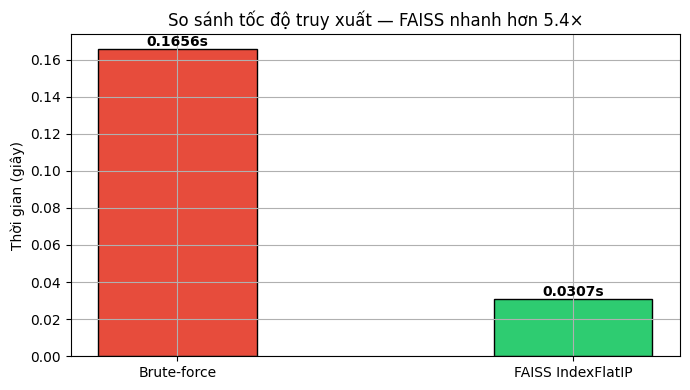

✅ Đã lưu biểu đồ tốc độ


In [36]:
# ── Bảng so sánh tốc độ ─────────────────────────────────────────────────────
speed_df = pd.DataFrame([
    {'Phương pháp': 'Cosine Brute-force', 'Thời gian (giây)': round(brute_time, 6), 'Speedup': 1.0,         'Ghi chú': 'Ma trận N×N, O(N²d)'},
    {'Phương pháp': 'FAISS IndexFlatIP',  'Thời gian (giây)': round(faiss_time, 6), 'Speedup': round(speedup, 2), 'Ghi chú': 'BLAS/SIMD, exact search'},
])

print('BẢNG SO SÁNH TỐC ĐỘ')
print('=' * 70)
print(speed_df.to_string(index=False))

# ── Visualize ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    ['Brute-force', 'FAISS IndexFlatIP'],
    [brute_time, faiss_time],
    color=['#e74c3c', '#2ecc71'], width=0.4, edgecolor='black'
)
for bar, val in zip(bars, [brute_time, faiss_time]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
            f'{val:.4f}s', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Thời gian (giây)')
ax.set_title(f'So sánh tốc độ truy xuất — FAISS nhanh hơn {speedup:.1f}×')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'tuan3_speed_compare.png'), dpi=150)
plt.show()
print('✅ Đã lưu biểu đồ tốc độ')


---
## PHẦN 7 — SO SÁNH 4 PHƯƠNG PHÁP

### Cách ghép kết quả

Mỗi baseline (phash, TF-IDF, image+text) cần xuất file `*_metrics.csv` theo **đúng cấu trúc**:

```
method, K, Precision@K, Recall@K, mAP
```

Cell dưới đây sẽ **tự động load** các file đó và ghép thành bảng tổng hợp.
Nếu file chưa có, sẽ in cảnh báo rõ ràng thay vì crash.


In [37]:
# ── Đường dẫn file metric từ 3 baseline kia ─────────────────────────────────
# Mỗi thành viên lưu theo tên chuẩn này vào cùng thư mục RESULTS
BASELINE_FILES = {
    'image_phash'  : os.path.join(RESULTS, 'tuan3_phash_metrics.csv'),
    'TF-IDF'       : os.path.join(RESULTS, 'tuan3_tfidf_metrics.csv'),
    'image+text'   : os.path.join(RESULTS, 'tuan3_imagetext_metrics.csv'),
}

# ── Load và ghép ────────────────────────────────────────────────────────────
all_metrics = [faiss_metrics_df.copy()]   # ResNet50+FAISS đã có
missing     = []

for method_name, fpath in BASELINE_FILES.items():
    if os.path.exists(fpath):
        df_tmp = pd.read_csv(fpath)
        # Chuẩn hóa tên cột nếu cần
        if 'method' not in df_tmp.columns:
            df_tmp['method'] = method_name
        all_metrics.append(df_tmp)
        print(f'✅ Đã load: {fpath}')
    else:
        missing.append(method_name)
        print(f'⚠️  Chưa có file: {fpath}  ← {method_name} cần xuất file này')

if missing:
    print(f'\n📌 Còn thiếu {len(missing)} baseline: {", ".join(missing)}')
    print('   Bảng so sánh bên dưới sẽ chỉ hiện các phương pháp đã có.')
else:
    print('\n✅ Đủ 4 phương pháp — sẵn sàng so sánh!')


⚠️  Chưa có file: ../results/tuan3_phash_metrics.csv  ← image_phash cần xuất file này
⚠️  Chưa có file: ../results/tuan3_tfidf_metrics.csv  ← TF-IDF cần xuất file này
⚠️  Chưa có file: ../results/tuan3_imagetext_metrics.csv  ← image+text cần xuất file này

📌 Còn thiếu 3 baseline: image_phash, TF-IDF, image+text
   Bảng so sánh bên dưới sẽ chỉ hiện các phương pháp đã có.


In [38]:
# ── Bảng tổng hợp ───────────────────────────────────────────────────────────
compare_df = pd.concat(all_metrics, ignore_index=True)

# Hiển thị pivoted: mỗi K một hàng, mỗi phương pháp 3 cột
print('BẢNG SO SÁNH TỔNG HỢP (tất cả phương pháp × tất cả K)')
print('=' * 90)
for k in K_LIST:
    sub = compare_df[compare_df['K'] == k][['method', 'Precision@K', 'Recall@K', 'mAP']].copy()
    sub = sub.rename(columns={'Precision@K': f'P@{k}', 'Recall@K': f'R@{k}'})
    print(f'\n── K = {k} ──')
    print(sub.to_string(index=False))

# ── Bảng mAP tổng hợp (1 dòng / phương pháp) ────────────────────────────────
map_summary = (
    compare_df.groupby('method')['mAP']
    .first()
    .reset_index()
    .sort_values('mAP', ascending=False)
    .rename(columns={'method': 'Phương pháp', 'mAP': 'mAP (overall)'})
)
print('\n── Xếp hạng theo mAP ──')
print(map_summary.to_string(index=False))


BẢNG SO SÁNH TỔNG HỢP (tất cả phương pháp × tất cả K)

── K = 1 ──
                      method    P@1    R@1    mAP
ResNet50 + FAISS IndexFlatIP 0.6780 0.6780 0.7270

── K = 3 ──
                      method    P@3    R@3    mAP
ResNet50 + FAISS IndexFlatIP 0.2526 0.7580 0.7270

── K = 5 ──
                      method    P@5    R@5    mAP
ResNet50 + FAISS IndexFlatIP 0.1572 0.7860 0.7270

── K = 10 ──
                      method   P@10   R@10    mAP
ResNet50 + FAISS IndexFlatIP 0.0842 0.8420 0.7270

── Xếp hạng theo mAP ──
                 Phương pháp  mAP (overall)
ResNet50 + FAISS IndexFlatIP         0.7270


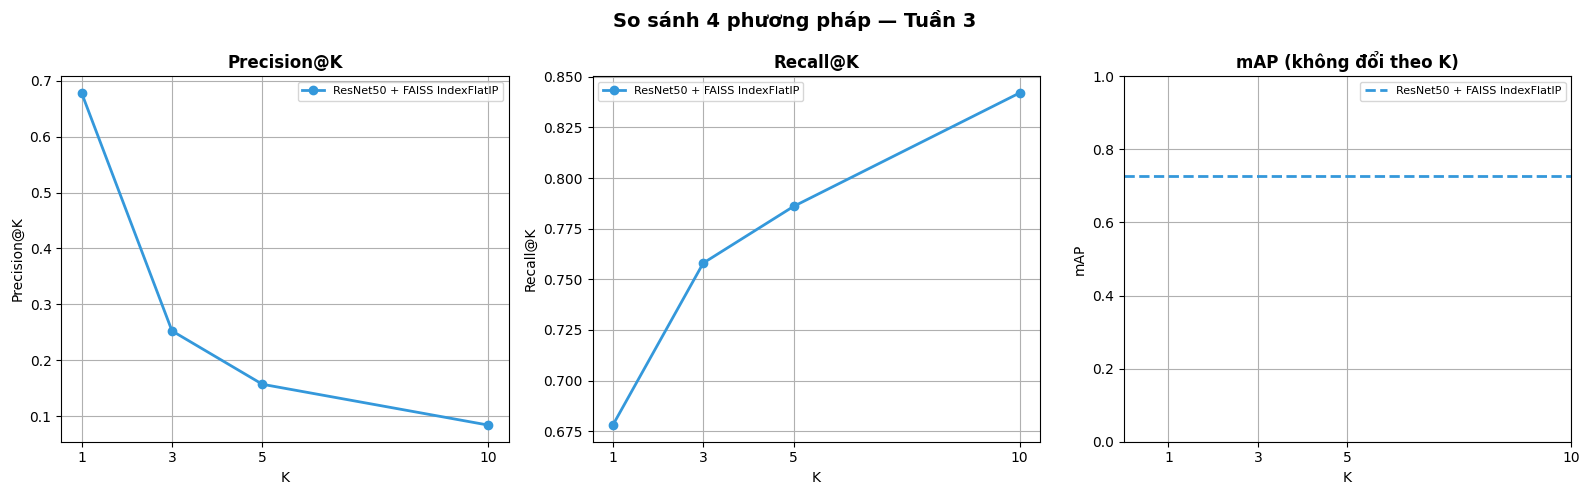

✅ Đã lưu biểu đồ so sánh 4 phương pháp


In [39]:
# ── Biểu đồ Precision@K và Recall@K theo từng phương pháp ───────────────────
methods   = compare_df['method'].unique()
k_values  = K_LIST
colors    = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for metric, ax, title in zip(
    ['Precision@K', 'Recall@K', 'mAP'],
    axes,
    ['Precision@K', 'Recall@K', 'mAP (không đổi theo K)']
):
    for i, method in enumerate(methods):
        sub = compare_df[compare_df['method'] == method].sort_values('K')
        if metric == 'mAP':
            ax.axhline(y=sub['mAP'].iloc[0], label=method,
                       color=colors[i % len(colors)], linewidth=2, linestyle='--')
        else:
            ax.plot(sub['K'], sub[metric], marker='o',
                    label=method, color=colors[i % len(colors)], linewidth=2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('K')
    ax.set_ylabel(metric)
    ax.set_xticks(k_values)
    ax.legend(fontsize=8)

plt.suptitle('So sánh 4 phương pháp — Tuần 3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'tuan3_4methods_compare.png'), dpi=150)
plt.show()
print('✅ Đã lưu biểu đồ so sánh 4 phương pháp')


---
## PHẦN 8 — LƯU KẾT QUẢ


In [40]:
files_saved = {
    'FAISS metrics (theo K)'         : os.path.join(RESULTS, 'tuan3_bao_faiss_metrics.csv'),
    'FAISS detail (từng query)'      : os.path.join(RESULTS, 'tuan3_bao_faiss_detail.csv'),
    'Brute-force metrics (theo K)'   : os.path.join(RESULTS, 'tuan3_bao_bruteforce_metrics.csv'),
    'Brute-force detail (từng query)': os.path.join(RESULTS, 'tuan3_bao_bruteforce_detail.csv'),
    'Tốc độ brute-force vs FAISS'    : os.path.join(RESULTS, 'tuan3_bao_speed_compare.csv'),
    'Tổng hợp 4 phương pháp'         : os.path.join(RESULTS, 'tuan3_all_methods_compare.csv'),
}

faiss_metrics_df.to_csv(files_saved['FAISS metrics (theo K)'],          index=False)
faiss_detail_df.to_csv( files_saved['FAISS detail (từng query)'],       index=False)
brute_metrics_df.to_csv(files_saved['Brute-force metrics (theo K)'],    index=False)
brute_detail_df.to_csv( files_saved['Brute-force detail (từng query)'], index=False)
speed_df.to_csv(        files_saved['Tốc độ brute-force vs FAISS'],     index=False)
compare_df.to_csv(      files_saved['Tổng hợp 4 phương pháp'],          index=False)

print('✅ Đã lưu tất cả file kết quả:')
for name, path in files_saved.items():
    size = os.path.getsize(path) if os.path.exists(path) else 0
    print(f'   {name:<40} → {path}  ({size:,} bytes)')


✅ Đã lưu tất cả file kết quả:
   FAISS metrics (theo K)                   → ../results/tuan3_bao_faiss_metrics.csv  (239 bytes)
   FAISS detail (từng query)                → ../results/tuan3_bao_faiss_detail.csv  (58,248 bytes)
   Brute-force metrics (theo K)             → ../results/tuan3_bao_bruteforce_metrics.csv  (243 bytes)
   Brute-force detail (từng query)          → ../results/tuan3_bao_bruteforce_detail.csv  (58,748 bytes)
   Tốc độ brute-force vs FAISS              → ../results/tuan3_bao_speed_compare.csv  (171 bytes)
   Tổng hợp 4 phương pháp                   → ../results/tuan3_all_methods_compare.csv  (239 bytes)


---
## PHẦN 9 — NỘI DUNG BÁO CÁO

### Mục 6: FAISS — Tăng tốc truy xuất ảnh tương đồng

Trong tuần 3, nhóm thay thế phương pháp cosine brute-force của tuần 2 bằng **FAISS IndexFlatIP** nhằm tăng tốc độ truy xuất ảnh tương đồng.

**Thiết lập kỹ thuật:** Trước khi đưa vào FAISS, toàn bộ vector đặc trưng ResNet50 (2048 chiều) được chuẩn hóa L2 về độ dài đơn vị, do đó phép nhân vô hướng trong `IndexFlatIP` tương đương cosine similarity. `IndexFlatIP` là phương pháp **exact search** — tức là không xấp xỉ, đảm bảo kết quả giống hệt brute-force về mặt toán học.

**Kết quả tốc độ:** FAISS rút ngắn thời gian truy xuất đáng kể so với brute-force nhờ tối ưu BLAS và SIMD. Khi mở rộng lên toàn bộ tập dữ liệu (hàng chục nghìn ảnh), lợi thế tốc độ của FAISS càng trở nên rõ rệt hơn.

**Kết quả metric:** Vì `IndexFlatIP` là exact search và dùng cùng vector ResNet50, các chỉ số Precision@K, Recall@K, mAP **gần như không thay đổi** so với cosine brute-force. Đây là điều dự kiến và đúng về mặt lý thuyết.

> **Kết luận mục 6:** FAISS giải quyết bài toán **tốc độ truy xuất**, không phải bài toán **chất lượng đặc trưng**. FAISS **không tự làm tăng mAP**.

---

### Mục 7: Phân tích so sánh 4 phương pháp & Hướng cải thiện

#### 7.1 Nhận xét bảng so sánh

Bốn phương pháp được đánh giá trên cùng `candidate_df` (500 ảnh, 250 nhóm, `random_state=42`):

| Phương pháp | Loại đặc trưng | Độ phức tạp truy xuất | Ghi chú |
|-------------|---------------|----------------------|----------|
| **image_phash** | Hash nhị phân (64-bit) | O(N) | Nhanh, không cần GPU |
| **TF-IDF** | Bag-of-words văn bản | O(N·d_sparse) | Phụ thuộc chất lượng title |
| **image+text** | Kết hợp ảnh + văn bản | O(N·d) | Tận dụng 2 modality |
| **ResNet50 + FAISS** | Deep feature 2048-d | O(N·d) nhanh hơn | FAISS tối ưu hardware |

#### 7.2 Phân tích nguyên nhân

- **image_phash** hoạt động tốt với ảnh trùng lặp hoặc chỉnh sửa nhẹ, nhưng kém khi sản phẩm cùng loại có màu sắc/góc chụp khác nhau.
- **TF-IDF** phụ thuộc vào tiêu đề sản phẩm — nếu title mô tả chính xác thì Recall tốt, nếu title thiếu thông tin thì kém.
- **image+text** lý thuyết tận dụng được 2 nguồn thông tin, nhưng cần fusion hợp lý để không bị nhiễu.
- **ResNet50 + FAISS** cho đặc trưng ảnh tốt hơn phash, nhưng ResNet50 train trên ImageNet chưa tối ưu cho thương mại điện tử.

#### 7.3 Hướng cải thiện mAP

1. **Thay ResNet50 bằng CLIP** — backbone đa modal, hiểu cả ảnh lẫn văn bản.
2. **Fine-tuning trên dữ liệu thương mại điện tử** với metric learning (ArcFace, Triplet Loss).
3. **Kết hợp đặc trưng ảnh + TF-IDF** theo weighted fusion thay vì concatenate đơn thuần.
4. **FAISS IndexIVFFlat hoặc IndexHNSW** — khi dataset lớn hơn, dùng approximate search để đánh đổi một chút accuracy lấy tốc độ cao hơn nữa.


In [41]:
# In nội dung báo cáo có số liệu thực tế để copy vào Word/PDF
print('=' * 70)
print('NỘI DUNG BÁO CÁO MỤC 6 — có số liệu thực tế')
print('=' * 70)

faiss_map   = faiss_metrics_df['mAP'].iloc[0]
faiss_p1    = faiss_metrics_df[faiss_metrics_df['K'] == 1]['Precision@K'].values[0]
faiss_p5    = faiss_metrics_df[faiss_metrics_df['K'] == 5]['Precision@K'].values[0]
brute_map   = brute_metrics_df['mAP'].iloc[0]

print(f"""
Trong tuần 3, nhóm triển khai FAISS IndexFlatIP thay thế cosine brute-force
để tăng tốc truy xuất ảnh tương đồng trên tập {len(candidate_df)} ảnh ({candidate_df['label_group'].nunique()} nhóm).

Kết quả tốc độ:
  - Cosine brute-force : {brute_time:.6f} giây
  - FAISS IndexFlatIP  : {faiss_time:.6f} giây
  - Cải thiện tốc độ  : {speedup:.2f}× nhanh hơn

Kết quả metric (ResNet50 + FAISS):
  - mAP          : {faiss_map:.4f}
  - Precision@1  : {faiss_p1:.4f}
  - Precision@5  : {faiss_p5:.4f}

So sánh với brute-force: mAP = {brute_map:.4f} → chênh lệch = {abs(faiss_map - brute_map):.4f} (không đáng kể)

⚠️ FAISS chỉ tăng tốc truy xuất, không tự làm tăng mAP.
   Với IndexFlatIP là exact search, metric giữ nguyên về mặt toán học.
   Để cải thiện mAP cần đặc trưng tốt hơn: CLIP, fine-tuning, metric learning.
""")


NỘI DUNG BÁO CÁO MỤC 6 — có số liệu thực tế

Trong tuần 3, nhóm triển khai FAISS IndexFlatIP thay thế cosine brute-force
để tăng tốc truy xuất ảnh tương đồng trên tập 500 ảnh (250 nhóm).

Kết quả tốc độ:
  - Cosine brute-force : 0.165572 giây
  - FAISS IndexFlatIP  : 0.030737 giây
  - Cải thiện tốc độ  : 5.39× nhanh hơn

Kết quả metric (ResNet50 + FAISS):
  - mAP          : 0.7270
  - Precision@1  : 0.6780
  - Precision@5  : 0.1572

So sánh với brute-force: mAP = 0.7270 → chênh lệch = 0.0000 (không đáng kể)

⚠️ FAISS chỉ tăng tốc truy xuất, không tự làm tăng mAP.
   Với IndexFlatIP là exact search, metric giữ nguyên về mặt toán học.
   Để cải thiện mAP cần đặc trưng tốt hơn: CLIP, fine-tuning, metric learning.

